<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/CO2_low_temperature_compression_relief_and_depressurization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CO₂ low-temperature analysis: compression, relief, and depressurization

This notebook is a reproducible, project-independent engineering study of a CO₂-rich
stream compressed from about **1.6 bara** to **70 bara** and cooled to **20–25 °C**.
It focuses on thermodynamic model selection and on the low temperatures that can occur
during throttling, pressure relief, and vessel blowdown.

The calculations combine:

- NeqSim **SRK**, **PR**, **GERG-2008**, and **EOS-CG** models;
- the Span–Wagner pure-CO₂ reference equation through CoolProp HEOS;
- a five-stage compression train with intercooling;
- an isenthalpic downstream-flash screen;
- a homogeneous-equilibrium-model (HEM) nozzle screen; and
- a transient rigid-vessel blowdown with a lumped metal-wall heat balance.

All pressures are absolute. Inputs and compositions are synthetic and editable. The
notebook is an engineering screening study, not certified pressure-relief sizing,
materials qualification, or a replacement for the governing design standard.

## Questions answered

1. Is a CO₂-rich stream at 70 bara and 20–25 °C gas, liquid-like, or two phase?
2. How different are PR and SRK from EOS-CG and a pure-CO₂ reference near this state?
3. How sensitive is the final phase state to small amounts of N₂, O₂, and Ar?
4. What temperatures are predicted across an isenthalpic restriction?
5. What is the HEM critical mass flux and how sensitive is it to inlet temperature?
6. How cold can the fluid and vessel wall become during an illustrative blowdown?
7. Which results can be used for screening, and which require a qualified relief,
   dispersion, solid-CO₂, or mechanical-design method?

## Scope, basis, and safety boundary

| Item | Demonstration basis |
|---|---:|
| Suction pressure | 1.6 bara |
| Suction temperature | 40 °C |
| Final pressure | 70 bara |
| Intercooler outlet | 25 °C |
| Optional final cooling | 20–25 °C |
| Mass flow | 100,000 kg/h |
| Compressor stages | 5, equal pressure ratio |
| Isentropic efficiency | 78% per stage |
| Nominal dry composition | 99.0 mol% CO₂, 0.5% N₂, 0.3% O₂, 0.2% Ar |
| Blowdown vessel | 10 m³, initially 70 bara and 25 °C |
| Illustrative vent bore | 20 mm, discharge coefficient 0.85 |

The dry composition isolates EOS and phase-behaviour effects. Real capture streams can
also contain water and trace reactive species. Water dropout, ice, hydrate, corrosion,
and aqueous chemistry require a separate water-qualified model such as CPA plus validated
interaction parameters. A dry-gas result must never be interpreted as proof that no
aqueous or solid phase can form.

The pressure-relief calculations below are deliberately labelled **HEM screens**. Final
device selection and sizing must address certified capacity, inlet and outlet losses,
backpressure, discharge coefficients, two-phase nonequilibrium, reaction forces, noise,
dispersion, materials, and the applicable approved standard.

## Thermodynamic models and their roles

| Model | Best role in this notebook | Important limitation |
|---|---|---|
| Span–Wagner | Reference properties for pure fluid CO₂ | Not a mixture or solid model |
| EOS-CG / EOS-CG-2021 | Reference-quality CCS and combustion-gas mixtures | Fluid-phase equilibrium does not by itself qualify dry-ice prediction |
| GERG-2008 | Reference-quality natural-gas component mixtures | Not tailored to every CCS impurity or aqueous chemistry |
| PR | Robust process and equipment screening | Cubic EOS errors grow near critical and dense-fluid regions |
| SRK | Robust process and equipment screening | Same general cubic-EOS limitations as PR |
| CPA family | Water association and aqueous-phase screening | Not used here as the dense-CO₂ reference |

PR and SRK have the generic cubic form

$$p=\frac{RT}{v-b}-\frac{a\alpha(T)}{v^2+u b v+w b^2}$$

with model-specific constants $u$ and $w$. EOS-CG uses dimensionless Helmholtz energy,

$$\alpha(\delta,\tau,\mathbf{x})=\alpha^0(\delta,\tau,\mathbf{x})+\alpha^r(\delta,\tau,\mathbf{x})$$

and obtains pressure and caloric properties from derivatives of $\alpha$. That richer
derivative structure is the reason a reference EOS can reproduce dense-fluid density,
heat capacity, and speed of sound more accurately than a simple cubic EOS.

## Clean Colab setup

The released Python package supplies the JPype bridge. The next cell clones and builds
current `equinor/neqsim` `master`, records the exact source commit and JAR SHA-256, and
verifies that a class added after the latest release is loaded from that JAR before any
calculation. CoolProp is pinned as the independent pure-CO₂ reference.

For clean local or CI validation, `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` may point
to a checked-out `master` commit and its source-built runtime JAR. Colab follows the
clone-and-build path.

In [1]:
import importlib.metadata
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys

required_versions = {
    "neqsim": "3.17.0",
    "CoolProp": "8.0.0",
}

needs_install = False
for package_name, required_version in required_versions.items():
    try:
        installed_version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        needs_install = True
        break
    if installed_version != required_version:
        needs_install = True
        break

if needs_install:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "neqsim==3.17.0",
            "CoolProp==8.0.0",
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in (
                    "sources",
                    "javadoc",
                    "tests",
                    "original",
                )
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(
        jar_candidates,
        key=lambda path: len(path.name),
    )[0]

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-co2-relief")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the source JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
from neqsim.neqsimpython import init_jvm


init_jvm()
MAIN_ONLY_CLASS = jpype.JClass(
    "neqsim.process.dynamics.DynamicCapabilityReport"
)
LOADED_JAR_LOCATION = str(
    MAIN_ONLY_CLASS.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION

print(f"NeqSim bridge: {importlib.metadata.version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Loaded main-only class from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")

NeqSim bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: ef31a3ba78a325b5784a33486bb047a264425412
NeqSim source JAR SHA-256: d1cb2dd3044467f31ebbed3ace48d32bd55fc2167f08211ad62eb62e5de1a91a
Loaded main-only class from: file:/tmp/neqsim-current-master-runtime/neqsim-3.17.0.jar
Python runtime: 3.12.13


In [2]:
import math
import time

import CoolProp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from CoolProp.CoolProp import PropsSI
from IPython.display import display
from matplotlib.colors import ListedColormap
from neqsim import jneqsim

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)
pd.set_option("display.max_columns", 30)

runtime = {
    "NeqSim bridge": importlib.metadata.version("neqsim"),
    "NeqSim source commit": NEQSIM_SOURCE_COMMIT[:12],
    "Source JAR SHA-256": SOURCE_JAR_SHA256[:16],
    "CoolProp": CoolProp.__version__,
    "Python": platform.python_version(),
    "Java": subprocess.check_output(
        ["java", "-version"],
        stderr=subprocess.STDOUT,
        text=True,
    ).splitlines()[0],
}
display(pd.DataFrame([runtime]))

,NeqSim bridge,NeqSim source commit,Source JAR SHA-256,CoolProp,Python,Java
0,3.17.0,ef31a3ba78a3,d1cb2dd3044467f3,8.0.0,3.12.13,"openjdk version ""17.0.19"" 2026-04-21"


## CO₂ landmarks and synthetic compositions

For pure CO₂, the critical point is close to 31 °C and 73.8 bara. The final condition
of 70 bara and 20–25 °C is therefore **subcritical but close to the vapour–liquid
boundary**. It should not be called supercritical.

The triple point is approximately 216.59 K and 5.18 bara. A fluid-only vapour–liquid
flash below this pressure can be metastable or physically incomplete because solid CO₂
may be the stable condensed phase. The notebook stops the fluid blowdown just above this
boundary and flags the residual dry-ice problem.

In [3]:
CO2_CRITICAL_TEMPERATURE_K = PropsSI("Tcrit", "CO2")
CO2_CRITICAL_PRESSURE_PA = PropsSI("pcrit", "CO2")
CO2_TRIPLE_TEMPERATURE_K = PropsSI("Ttriple", "CO2")
CO2_TRIPLE_PRESSURE_PA = PropsSI(
    "P",
    "T",
    CO2_TRIPLE_TEMPERATURE_K,
    "Q",
    0,
    "CO2",
)

NOMINAL_COMPOSITION = {
    "CO2": 0.990,
    "nitrogen": 0.005,
    "oxygen": 0.003,
    "argon": 0.002,
}

MODEL_CLASSES = {
    "SRK": jneqsim.thermo.system.SystemSrkEos,
    "PR": jneqsim.thermo.system.SystemPrEos,
    "GERG-2008": jneqsim.thermo.system.SystemGERG2008Eos,
    "EOS-CG": jneqsim.thermo.system.SystemEOSCGEos,
}

assert math.isclose(
    sum(NOMINAL_COMPOSITION.values()),
    1.0,
    abs_tol=1.0e-12,
)

landmarks = pd.DataFrame(
    [
        {
            "Landmark": "Critical point",
            "Temperature [°C]": CO2_CRITICAL_TEMPERATURE_K - 273.15,
            "Pressure [bara]": CO2_CRITICAL_PRESSURE_PA / 1.0e5,
        },
        {
            "Landmark": "Triple point",
            "Temperature [°C]": CO2_TRIPLE_TEMPERATURE_K - 273.15,
            "Pressure [bara]": CO2_TRIPLE_PRESSURE_PA / 1.0e5,
        },
    ]
)
display(landmarks.round(5))

,Landmark,Temperature [°C],Pressure [bara]
0,Critical point,30.9782,73.77298
1,Triple point,-56.5580,5.17964


# Part 1 — Pure-CO₂ benchmark against Span–Wagner

CoolProp's HEOS backend implements the Span–Wagner reference equation for pure CO₂.
The first benchmark compares equilibrium density at 70 bara. Enthalpy values are not
compared directly because different packages can use different reference zeros; density
is absolute and unambiguous.

In [4]:
def build_neqsim_fluid(
    model_name,
    temperature_k,
    pressure_bara,
    composition,
):
    fluid = MODEL_CLASSES[model_name](temperature_k, pressure_bara)
    for component_name, mole_fraction in composition.items():
        if mole_fraction > 0.0:
            fluid.addComponent(component_name, mole_fraction)
    if model_name in {"SRK", "PR"}:
        fluid.setMixingRule("classic")
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()
    return fluid


def gas_phase_beta(fluid):
    if int(fluid.getNumberOfPhases()) < 2:
        return np.nan
    for phase_index in range(int(fluid.getNumberOfPhases())):
        phase_type = str(fluid.getPhase(phase_index).getType()).upper()
        if phase_type == "GAS":
            return float(fluid.getBeta(phase_index))
    return np.nan


benchmark_temperatures_c = [0.0, 10.0, 20.0, 25.0]
pure_density_records = []

for temperature_c in benchmark_temperatures_c:
    temperature_k = temperature_c + 273.15
    reference_density = PropsSI(
        "Dmass",
        "T",
        temperature_k,
        "P",
        70.0e5,
        "CO2",
    )
    for model_name in MODEL_CLASSES:
        fluid = build_neqsim_fluid(
            model_name,
            temperature_k,
            70.0,
            {"CO2": 1.0},
        )
        density = float(fluid.getDensity("kg/m3"))
        pure_density_records.append(
            {
                "Temperature [°C]": temperature_c,
                "Model": model_name,
                "Density [kg/m³]": density,
                "Span-Wagner [kg/m³]": reference_density,
                "Relative error [%]": 100.0
                * (density - reference_density)
                / reference_density,
            }
        )

pure_density_table = pd.DataFrame(pure_density_records)
display(pure_density_table.round(4))

,Temperature [°C],Model,Density [kg/m³],Span-Wagner [kg/m³],Relative error [%]
0,0.0,SRK,906.2500,955.3124,-5.1357
1,0.0,PR,920.3198,955.3124,-3.6630
2,0.0,GERG-2008,955.6136,955.3124,0.0315
3,0.0,EOS-CG,955.6136,955.3124,0.0315
4,10.0,SRK,823.9075,893.1070,-7.7482
5,10.0,PR,842.3064,893.1070,-5.6881
6,10.0,GERG-2008,893.2575,893.1070,0.0169
7,10.0,EOS-CG,893.2575,893.1070,0.0169
8,20.0,SRK,714.0050,808.6001,-11.6986
9,20.0,PR,735.2564,808.6001,-9.0704


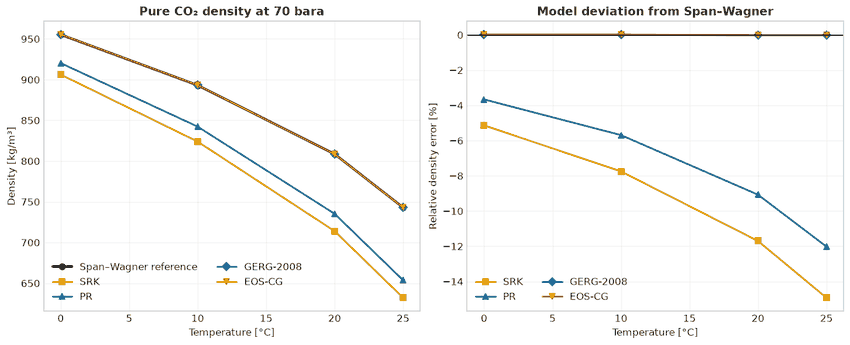

In [5]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.8),
    constrained_layout=True,
)

reference_subset = (
    pure_density_table[
        pure_density_table["Model"] == "EOS-CG"
    ]
    .sort_values("Temperature [°C]")
)
axes[0].plot(
    reference_subset["Temperature [°C]"],
    reference_subset["Span-Wagner [kg/m³]"],
    color="black",
    linewidth=2.5,
    marker="o",
    label="Span–Wagner reference",
)

model_styles = {
    "SRK": ("#E69F00", "s"),
    "PR": ("#0072B2", "^"),
    "GERG-2008": ("#009E73", "D"),
    "EOS-CG": ("#D55E00", "v"),
}

for model_name, (color, marker) in model_styles.items():
    subset = pure_density_table[
        pure_density_table["Model"] == model_name
    ].sort_values("Temperature [°C]")
    axes[0].plot(
        subset["Temperature [°C]"],
        subset["Density [kg/m³]"],
        color=color,
        marker=marker,
        linewidth=1.8,
        label=model_name,
    )
    axes[1].plot(
        subset["Temperature [°C]"],
        subset["Relative error [%]"],
        color=color,
        marker=marker,
        linewidth=1.8,
        label=model_name,
    )

axes[0].set_title("Pure CO₂ density at 70 bara")
axes[0].set_xlabel("Temperature [°C]")
axes[0].set_ylabel("Density [kg/m³]")
axes[0].legend(ncol=2)

axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].set_title("Model deviation from Span–Wagner")
axes[1].set_xlabel("Temperature [°C]")
axes[1].set_ylabel("Relative density error [%]")
axes[1].legend(ncol=2)
plt.show()

**Interpretation.** EOS-CG and GERG-2008 reproduce the Span–Wagner pure-CO₂ density
closely over the selected range. PR and SRK remain useful process models, but their
dense-fluid density errors become material as 70 bara approaches the saturation and
critical region. This affects contained mass, relief inventory, nozzle mass flux,
hydraulic pressure loss, and equipment volume.

## Saturation margin at 70 bara

The reference saturation pressure is evaluated from Span–Wagner. PR and SRK bubble-point
calculations are shown as process-model screens. At 25 °C, pure CO₂ has only a modest
pressure margin between 70 bara and saturation. Small permanent-gas impurities can move
the mixture boundary enough to change the phase state.

In [6]:
def cubic_saturation_pressure(model_name, temperature_k):
    fluid = MODEL_CLASSES[model_name](temperature_k, 50.0)
    fluid.addComponent("CO2", 1.0)
    fluid.setMixingRule("classic")
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.bubblePointPressureFlash(False)
    return float(fluid.getPressure("bara"))


saturation_records = []
for temperature_c in benchmark_temperatures_c:
    temperature_k = temperature_c + 273.15
    reference_pressure_bara = PropsSI(
        "P",
        "T",
        temperature_k,
        "Q",
        0,
        "CO2",
    ) / 1.0e5
    for model_name in ["SRK", "PR"]:
        model_pressure_bara = cubic_saturation_pressure(
            model_name,
            temperature_k,
        )
        saturation_records.append(
            {
                "Temperature [°C]": temperature_c,
                "Model": model_name,
                "Saturation pressure [bara]": model_pressure_bara,
                "Span-Wagner [bara]": reference_pressure_bara,
                "Relative error [%]": 100.0
                * (model_pressure_bara - reference_pressure_bara)
                / reference_pressure_bara,
                "Margin to 70 bara [bar]": 70.0
                - reference_pressure_bara,
            }
        )

saturation_table = pd.DataFrame(saturation_records)
display(saturation_table.round(4))

,Temperature [°C],Model,Saturation pressure [bara],Span-Wagner [bara],Relative error [%],Margin to 70 bara [bar]
0,0.0,SRK,35.0567,34.8514,0.5889,35.1486
1,0.0,PR,34.6779,34.8514,-0.4978,35.1486
2,10.0,SRK,45.3368,45.0218,0.6995,24.9782
3,10.0,PR,44.9585,45.0218,-0.1407,24.9782
4,20.0,SRK,57.6343,57.2905,0.6001,12.7095
5,20.0,PR,57.3530,57.2905,0.1091,12.7095
6,25.0,SRK,64.6072,64.3424,0.4115,5.6576
7,25.0,PR,64.4289,64.3424,0.1343,5.6576


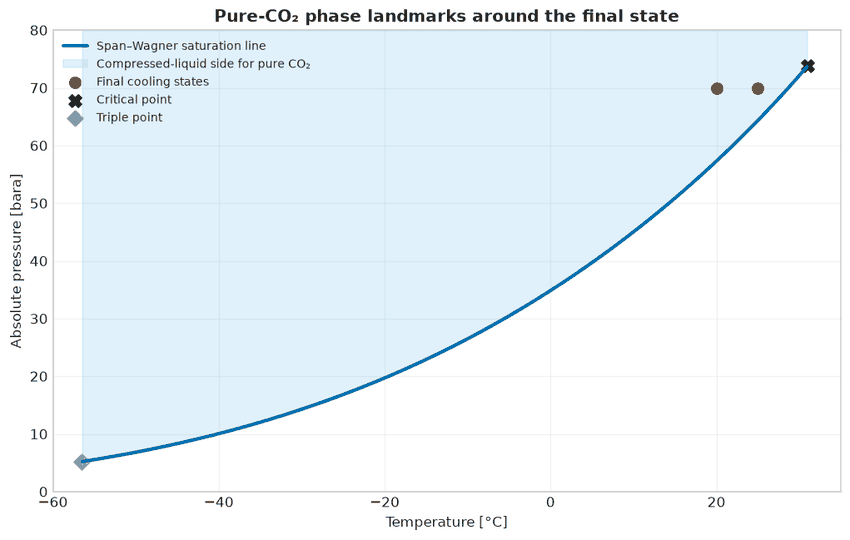

In [7]:
temperature_curve_k = np.linspace(
    CO2_TRIPLE_TEMPERATURE_K + 0.1,
    CO2_CRITICAL_TEMPERATURE_K - 0.05,
    220,
)
saturation_pressure_bara = np.array(
    [
        PropsSI("P", "T", temperature_k, "Q", 0, "CO2")
        / 1.0e5
        for temperature_k in temperature_curve_k
    ]
)

figure, axis = plt.subplots(
    figsize=(8.4, 5.3),
    constrained_layout=True,
)
axis.plot(
    temperature_curve_k - 273.15,
    saturation_pressure_bara,
    color="#0072B2",
    linewidth=2.5,
    label="Span–Wagner saturation line",
)
axis.fill_between(
    temperature_curve_k - 273.15,
    saturation_pressure_bara,
    80.0,
    color="#56B4E9",
    alpha=0.18,
    label="Compressed-liquid side for pure CO₂",
)
axis.scatter(
    [20.0, 25.0],
    [70.0, 70.0],
    color="#D55E00",
    s=65,
    zorder=5,
    label="Final cooling states",
)
axis.scatter(
    [CO2_CRITICAL_TEMPERATURE_K - 273.15],
    [CO2_CRITICAL_PRESSURE_PA / 1.0e5],
    color="black",
    marker="X",
    s=80,
    label="Critical point",
)
axis.scatter(
    [CO2_TRIPLE_TEMPERATURE_K - 273.15],
    [CO2_TRIPLE_PRESSURE_PA / 1.0e5],
    color="#CC79A7",
    marker="D",
    s=65,
    label="Triple point",
)
axis.set_xlim(-60.0, 35.0)
axis.set_ylim(0.0, 80.0)
axis.set_title("Pure-CO₂ phase landmarks around the final state")
axis.set_xlabel("Temperature [°C]")
axis.set_ylabel("Absolute pressure [bara]")
axis.legend(loc="upper left", fontsize=8.5)
plt.show()

# Part 2 — Impurity sensitivity with EOS-CG

The impurity split is kept at 50% N₂, 30% O₂, and 20% Ar while total impurity varies.
This is a controlled sensitivity, not a specification. Each state is rebuilt from a
fresh fluid object and flashed independently at 70 bara.

The key result is whether a separate gas and liquid phase is predicted. A model can
match pure-CO₂ density yet still give a different mixture phase boundary if the binary
interaction treatment is inadequate.

In [8]:
def impurity_composition(total_impurity_fraction):
    return {
        "CO2": 1.0 - total_impurity_fraction,
        "nitrogen": 0.50 * total_impurity_fraction,
        "oxygen": 0.30 * total_impurity_fraction,
        "argon": 0.20 * total_impurity_fraction,
    }


impurity_grid = np.linspace(0.0, 0.04, 21)
impurity_records = []

for temperature_c in [20.0, 25.0]:
    for impurity_fraction in impurity_grid:
        composition = impurity_composition(float(impurity_fraction))
        for model_name in MODEL_CLASSES:
            fluid = build_neqsim_fluid(
                model_name,
                temperature_c + 273.15,
                70.0,
                composition,
            )
            impurity_records.append(
                {
                    "Temperature [°C]": temperature_c,
                    "Impurity [mol%]": 100.0 * impurity_fraction,
                    "Model": model_name,
                    "Phases [-]": int(fluid.getNumberOfPhases()),
                    "Gas beta in split [-]": gas_phase_beta(fluid),
                    "Bulk density [kg/m³]": float(
                        fluid.getDensity("kg/m3")
                    ),
                }
            )

impurity_table = pd.DataFrame(impurity_records)

nominal_state_table = impurity_table[
    np.isclose(impurity_table["Impurity [mol%]"], 1.0)
].copy()
display(nominal_state_table.round(5))

,Temperature [°C],Impurity [mol%],Model,Phases [-],Gas beta in split [-],Bulk density [kg/m³]
20,20.0,1.0,SRK,1,NaN,693.12641
21,20.0,1.0,PR,1,NaN,714.59256
22,20.0,1.0,GERG-2008,1,NaN,787.30202
23,20.0,1.0,EOS-CG,1,NaN,787.30202
104,25.0,1.0,SRK,1,NaN,598.89326
105,25.0,1.0,PR,1,NaN,620.43089
106,25.0,1.0,GERG-2008,2,0.03087,668.89520
107,25.0,1.0,EOS-CG,2,0.03087,668.89520


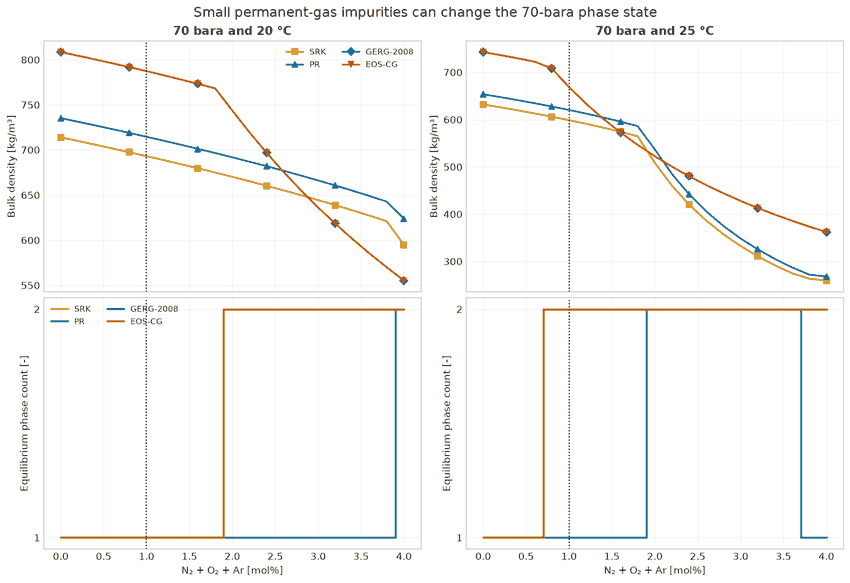

In [9]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 8.2),
    sharex=True,
    constrained_layout=True,
)

for column_index, temperature_c in enumerate([20.0, 25.0]):
    for model_name, (color, marker) in model_styles.items():
        subset = impurity_table[
            (impurity_table["Temperature [°C]"] == temperature_c)
            & (impurity_table["Model"] == model_name)
        ]
        axes[0, column_index].plot(
            subset["Impurity [mol%]"],
            subset["Bulk density [kg/m³]"],
            color=color,
            marker=marker,
            markevery=4,
            linewidth=1.8,
            label=model_name,
        )
        axes[1, column_index].step(
            subset["Impurity [mol%]"],
            subset["Phases [-]"],
            where="mid",
            color=color,
            linewidth=2.0,
            label=model_name,
        )

    axes[0, column_index].set_title(
        f"70 bara and {temperature_c:.0f} °C"
    )
    axes[0, column_index].set_ylabel("Bulk density [kg/m³]")
    axes[1, column_index].set_xlabel("N₂ + O₂ + Ar [mol%]")
    axes[1, column_index].set_ylabel("Equilibrium phase count [-]")
    axes[1, column_index].set_yticks([1, 2])
    axes[0, column_index].axvline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=1.2,
    )
    axes[1, column_index].axvline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=1.2,
    )

axes[0, 0].legend(ncol=2, fontsize=8.5)
axes[1, 0].legend(ncol=2, fontsize=8.5)
figure.suptitle(
    "Small permanent-gas impurities can change the 70-bara phase state",
    fontsize=14,
)
plt.show()

**Interpretation.** The synthetic 1 mol% impurity case is deliberately near the phase
boundary at 25 °C. EOS-CG predicts a vapour–liquid split while PR and SRK remain
single phase. The disagreement is an engineering decision signal: do not tune a cubic
EOS silently or accept a single deterministic result. Obtain a measured composition,
define its uncertainty, select the qualified reference model, and bracket temperature
and pressure before closing the phase-state question.

GERG-2008 and EOS-CG overlap for this common component subset in the current NeqSim
implementation. EOS-CG remains the more directly motivated model family for the wider
CCS impurity set and humid combustion-gas mixtures.

## Final-cooler operability map

The following finite-grid EOS-CG map shows phase count versus final temperature and
total permanent-gas impurity at 70 bara. It is a screening map, not a traced or
certified phase envelope.

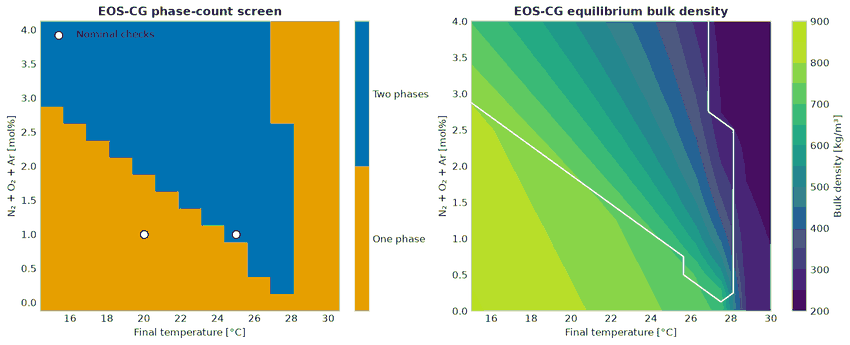

In [10]:
cooler_temperatures_c = np.linspace(15.0, 30.0, 13)
cooler_impurities_percent = np.linspace(0.0, 4.0, 17)
phase_count_map = np.zeros(
    (
        len(cooler_impurities_percent),
        len(cooler_temperatures_c),
    ),
    dtype=int,
)
density_map = np.zeros_like(phase_count_map, dtype=float)

for impurity_index, impurity_percent in enumerate(
    cooler_impurities_percent
):
    composition = impurity_composition(impurity_percent / 100.0)
    for temperature_index, temperature_c in enumerate(
        cooler_temperatures_c
    ):
        fluid = build_neqsim_fluid(
            "EOS-CG",
            temperature_c + 273.15,
            70.0,
            composition,
        )
        phase_count_map[impurity_index, temperature_index] = int(
            fluid.getNumberOfPhases()
        )
        density_map[impurity_index, temperature_index] = float(
            fluid.getDensity("kg/m3")
        )

phase_cmap = ListedColormap(["#E69F00", "#0072B2"])
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.8),
    constrained_layout=True,
)
phase_image = axes[0].pcolormesh(
    cooler_temperatures_c,
    cooler_impurities_percent,
    phase_count_map,
    cmap=phase_cmap,
    shading="nearest",
    vmin=1,
    vmax=2,
)
axes[0].scatter(
    [20.0, 25.0],
    [1.0, 1.0],
    color="white",
    edgecolor="black",
    s=65,
    label="Nominal checks",
)
axes[0].set_title("EOS-CG phase-count screen")
axes[0].set_xlabel("Final temperature [°C]")
axes[0].set_ylabel("N₂ + O₂ + Ar [mol%]")
axes[0].legend(loc="upper left")
colorbar = figure.colorbar(phase_image, ax=axes[0], ticks=[1.25, 1.75])
colorbar.ax.set_yticklabels(["One phase", "Two phases"])

density_image = axes[1].contourf(
    cooler_temperatures_c,
    cooler_impurities_percent,
    density_map,
    levels=14,
    cmap="viridis",
)
axes[1].contour(
    cooler_temperatures_c,
    cooler_impurities_percent,
    phase_count_map,
    levels=[1.5],
    colors="white",
    linewidths=1.5,
)
axes[1].set_title("EOS-CG equilibrium bulk density")
axes[1].set_xlabel("Final temperature [°C]")
axes[1].set_ylabel("N₂ + O₂ + Ar [mol%]")
density_colorbar = figure.colorbar(density_image, ax=axes[1])
density_colorbar.set_label("Bulk density [kg/m³]")
plt.show()

# Part 3 — Five-stage compression with PR and SRK

For an equal pressure ratio $r_p$ and $N$ stages,

$$r_p=\left(\frac{p_{\mathrm{out}}}{p_{\mathrm{in}}}\right)^{1/N}$$

The NeqSim process contains a named feed stream followed by five compressor, cooler,
and equilibrium separator blocks. Each downstream compressor receives the gas outlet
of the previous separator. PR and SRK are used here because their enthalpy methods are
well established in NeqSim process equipment; EOS-CG then audits the cooler outlet
states independently.

In [11]:
def build_compression_train(model_name):
    fluid = MODEL_CLASSES[model_name](313.15, 1.6)
    for component_name, mole_fraction in NOMINAL_COMPOSITION.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.setMixingRule("classic")

    feed = jneqsim.process.equipment.stream.Stream(
        f"{model_name} CO2-rich feed",
        fluid,
    )
    feed.setFlowRate(100_000.0, "kg/hr")
    feed.setTemperature(40.0, "C")
    feed.setPressure(1.6, "bara")

    stage_pressures_bara = np.geomspace(1.6, 70.0, 6)[1:]
    process = jneqsim.process.processmodel.ProcessSystem()
    process.add(feed)

    inlet_stream = feed
    compressors = []
    coolers = []
    separators = []

    for stage_number, stage_pressure_bara in enumerate(
        stage_pressures_bara,
        start=1,
    ):
        compressor = jneqsim.process.equipment.compressor.Compressor(
            f"{model_name} compressor {stage_number}",
            inlet_stream,
        )
        compressor.setOutletPressure(
            float(stage_pressure_bara),
            "bara",
        )
        compressor.setIsentropicEfficiency(0.78)

        cooler = jneqsim.process.equipment.heatexchanger.Cooler(
            f"{model_name} intercooler {stage_number}",
            compressor.getOutletStream(),
        )
        cooler.setOutTemperature(25.0, "C")

        separator = jneqsim.process.equipment.separator.Separator(
            f"{model_name} knockout {stage_number}",
            cooler.getOutletStream(),
        )

        for unit in [compressor, cooler, separator]:
            process.add(unit)

        compressors.append(compressor)
        coolers.append(cooler)
        separators.append(separator)
        inlet_stream = separator.getGasOutStream()

    return {
        "model": model_name,
        "process": process,
        "feed": feed,
        "compressors": compressors,
        "coolers": coolers,
        "separators": separators,
        "stage_pressures_bara": stage_pressures_bara,
    }


def compression_stage_table(train):
    rows = []
    for stage_number, (compressor, cooler, separator) in enumerate(
        zip(
            train["compressors"],
            train["coolers"],
            train["separators"],
        ),
        start=1,
    ):
        rows.append(
            {
                "Model": train["model"],
                "Stage": stage_number,
                "Suction [bara]": float(
                    compressor.getInletStream().getPressure("bara")
                ),
                "Discharge [bara]": float(
                    compressor.getOutletStream().getPressure("bara")
                ),
                "Discharge [°C]": float(
                    compressor.getOutletStream().getTemperature("C")
                ),
                "Power [MW]": float(compressor.getPower("MW")),
                "Cooler duty [MW]": float(cooler.getDuty()) / 1.0e6,
                "Gas out [kg/h]": float(
                    separator.getGasOutStream().getFlowRate("kg/hr")
                ),
                "Liquid out [kg/h]": float(
                    separator.getLiquidOutStream().getFlowRate("kg/hr")
                ),
                "Cubic outlet density [kg/m³]": float(
                    cooler.getOutletStream().getFluid().getDensity("kg/m3")
                ),
            }
        )
    return pd.DataFrame(rows)

In [12]:
compression_trains = {}
stage_tables = []

for model_name in ["SRK", "PR"]:
    train = build_compression_train(model_name)
    train["process"].run()
    compression_trains[model_name] = train
    stage_tables.append(compression_stage_table(train))

compression_results = pd.concat(stage_tables, ignore_index=True)
display(compression_results.round(5))

power_summary = (
    compression_results.groupby("Model", as_index=False)["Power [MW]"]
    .sum()
    .rename(columns={"Power [MW]": "Total power [MW]"})
)
display(power_summary.round(5))

,Model,Stage,Suction [bara],Discharge [bara],Discharge [°C],Power [MW],Cooler duty [MW],Gas out [kg/h],Liquid out [kg/h],Cubic outlet density [kg/m³]
0,SRK,1,1.60000,3.40656,110.21439,1.72299,-2.12700,100000.0,0.0,6.13637
1,SRK,2,3.40656,7.25289,93.39833,1.62604,-1.72609,100000.0,0.0,13.33482
2,SRK,3,7.25289,15.44212,93.97454,1.59427,-1.81923,100000.0,0.0,29.75618
3,SRK,4,15.44212,32.87778,95.06726,1.52492,-2.07741,100000.0,0.0,71.54155
4,SRK,5,32.87778,70.00000,96.31063,1.36648,-6.35754,100000.0,0.0,598.89326
5,PR,1,1.60000,3.40656,110.22136,1.72113,-2.12658,100000.0,0.0,6.14320
6,PR,2,3.40656,7.25289,93.41210,1.62208,-1.72533,100000.0,0.0,13.36673
7,PR,3,7.25289,15.44212,94.00395,1.58594,-1.81767,100000.0,0.0,29.91142
8,PR,4,15.44212,32.87778,95.12562,1.50772,-2.07441,100000.0,0.0,72.38611
9,PR,5,32.87778,70.00000,96.36320,1.33254,-6.34709,100000.0,0.0,620.43089


,Model,Total power [MW]
0,PR,7.76941
1,SRK,7.83471


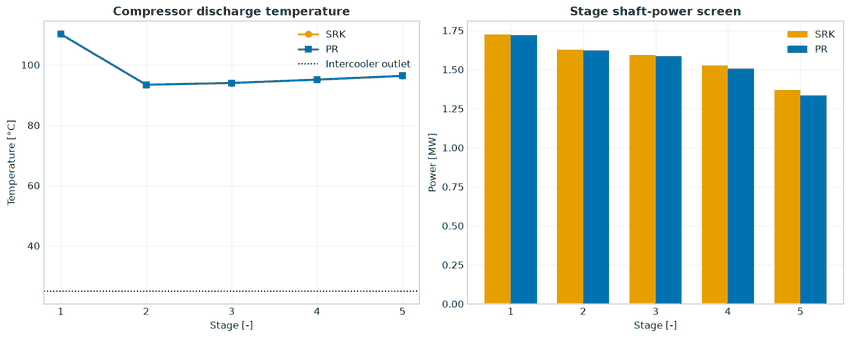

In [13]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.7),
    constrained_layout=True,
)

for model_name, color, marker in [
    ("SRK", "#E69F00", "o"),
    ("PR", "#0072B2", "s"),
]:
    subset = compression_results[
        compression_results["Model"] == model_name
    ]
    axes[0].plot(
        subset["Stage"],
        subset["Discharge [°C]"],
        color=color,
        marker=marker,
        linewidth=2.0,
        label=model_name,
    )
    axes[1].bar(
        subset["Stage"]
        + (-0.18 if model_name == "SRK" else 0.18),
        subset["Power [MW]"],
        width=0.36,
        color=color,
        label=model_name,
    )

axes[0].axhline(
    25.0,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="Intercooler outlet",
)
axes[0].set_title("Compressor discharge temperature")
axes[0].set_xlabel("Stage [-]")
axes[0].set_ylabel("Temperature [°C]")
axes[0].set_xticks(range(1, 6))
axes[0].legend()

axes[1].set_title("Stage shaft-power screen")
axes[1].set_xlabel("Stage [-]")
axes[1].set_ylabel("Power [MW]")
axes[1].set_xticks(range(1, 6))
axes[1].legend()
plt.show()

## EOS-CG audit of the compression path

The same cooler outlet temperatures, pressures, and nominal composition are rebuilt
with EOS-CG. This avoids assuming that a cubic process result is also the best available
property or phase-state result.

In [14]:
audit_records = []
for model_name in ["SRK", "PR"]:
    subset = compression_results[
        compression_results["Model"] == model_name
    ]
    for _, row in subset.iterrows():
        eoscg_fluid = build_neqsim_fluid(
            "EOS-CG",
            298.15,
            float(row["Discharge [bara]"]),
            NOMINAL_COMPOSITION,
        )
        audit_records.append(
            {
                "Process EOS": model_name,
                "Stage": int(row["Stage"]),
                "Pressure [bara]": float(row["Discharge [bara]"]),
                "Cubic density [kg/m³]": float(
                    row["Cubic outlet density [kg/m³]"]
                ),
                "EOS-CG density [kg/m³]": float(
                    eoscg_fluid.getDensity("kg/m3")
                ),
                "EOS-CG phases [-]": int(
                    eoscg_fluid.getNumberOfPhases()
                ),
                "EOS-CG gas beta [-]": gas_phase_beta(eoscg_fluid),
            }
        )

compression_audit = pd.DataFrame(audit_records)
display(compression_audit.round(6))

,Process EOS,Stage,Pressure [bara],Cubic density [kg/m³],EOS-CG density [kg/m³],EOS-CG phases [-],EOS-CG gas beta [-]
0,SRK,1,3.406556,6.136375,6.134344,1,NaN
1,SRK,2,7.252892,13.334815,13.325640,1,NaN
2,SRK,3,15.442116,29.756184,29.715589,1,NaN
3,SRK,4,32.877776,71.541549,71.396808,1,NaN
4,SRK,5,70.000000,598.893259,668.895198,2,0.030871
5,PR,1,3.406556,6.143201,6.134344,1,NaN
6,PR,2,7.252892,13.366725,13.325640,1,NaN
7,PR,3,15.442116,29.911420,29.715589,1,NaN
8,PR,4,32.877776,72.386106,71.396808,1,NaN
9,PR,5,70.000000,620.430885,668.895198,2,0.030871


**Interpretation.** The cubic models give a stable, composable compressor train and
similar total power. At the final cooler, however, EOS-CG changes both density and phase
classification. A sound workflow can therefore use a cubic EOS to construct and converge
the process while imposing a separate reference-EOS acceptance gate at near-critical,
dense-phase, custody, metering, relief, and pipeline interface states.

# Part 4 — Isenthalpic relief and downstream flash

For a restriction with negligible heat transfer and shaft work, the equilibrium
downstream screen uses

$$h_2=h_1$$

This predicts a final equilibrium state, not the valve throat, external jet, or metal
temperature. The pure-CO₂ reference path uses Span–Wagner. PR and SRK are applied to the
nominal mixture to expose model sensitivity. Calculations stop above the triple pressure;
below it, a vapour–liquid flash is not a complete equilibrium model.

In [15]:
def coolprop_isenthalpic_path(inlet_temperature_c):
    inlet_temperature_k = inlet_temperature_c + 273.15
    inlet_pressure_pa = 70.0e5
    inlet_enthalpy = PropsSI(
        "Hmass",
        "T",
        inlet_temperature_k,
        "P",
        inlet_pressure_pa,
        "CO2",
    )
    pressure_grid_bara = np.geomspace(
        70.0,
        1.014 * CO2_TRIPLE_PRESSURE_PA / 1.0e5,
        90,
    )
    rows = []
    for pressure_bara in pressure_grid_bara:
        pressure_pa = pressure_bara * 1.0e5
        temperature_k = PropsSI(
            "T",
            "P",
            pressure_pa,
            "Hmass",
            inlet_enthalpy,
            "CO2",
        )
        quality = PropsSI(
            "Q",
            "P",
            pressure_pa,
            "Hmass",
            inlet_enthalpy,
            "CO2",
        )
        density = PropsSI(
            "Dmass",
            "P",
            pressure_pa,
            "Hmass",
            inlet_enthalpy,
            "CO2",
        )
        rows.append(
            {
                "Path": f"Span–Wagner, inlet {inlet_temperature_c:.0f} °C",
                "Pressure [bara]": pressure_bara,
                "Temperature [°C]": temperature_k - 273.15,
                "Vapour quality [-]": quality,
                "Density [kg/m³]": density,
            }
        )
    return pd.DataFrame(rows)


def neqsim_isenthalpic_path(model_name, inlet_temperature_c):
    inlet_fluid = build_neqsim_fluid(
        model_name,
        inlet_temperature_c + 273.15,
        70.0,
        NOMINAL_COMPOSITION,
    )
    inlet_enthalpy = float(inlet_fluid.getEnthalpy("J/kg"))
    pressure_grid_bara = np.geomspace(
        70.0,
        6.0,
        70,
    )
    rows = []
    for pressure_bara in pressure_grid_bara:
        fluid = inlet_fluid.clone()
        fluid.setPressure(float(pressure_bara), "bara")
        operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(
            fluid
        )
        operations.PHflash(inlet_enthalpy, "J/kg")
        fluid.initProperties()
        rows.append(
            {
                "Path": f"{model_name}, nominal mixture",
                "Pressure [bara]": pressure_bara,
                "Temperature [°C]": float(fluid.getTemperature("C")),
                "Vapour quality [-]": gas_phase_beta(fluid),
                "Density [kg/m³]": float(fluid.getDensity("kg/m3")),
            }
        )
    return pd.DataFrame(rows)


relief_paths = pd.concat(
    [
        coolprop_isenthalpic_path(20.0),
        coolprop_isenthalpic_path(25.0),
        neqsim_isenthalpic_path("SRK", 25.0),
        neqsim_isenthalpic_path("PR", 25.0),
    ],
    ignore_index=True,
)

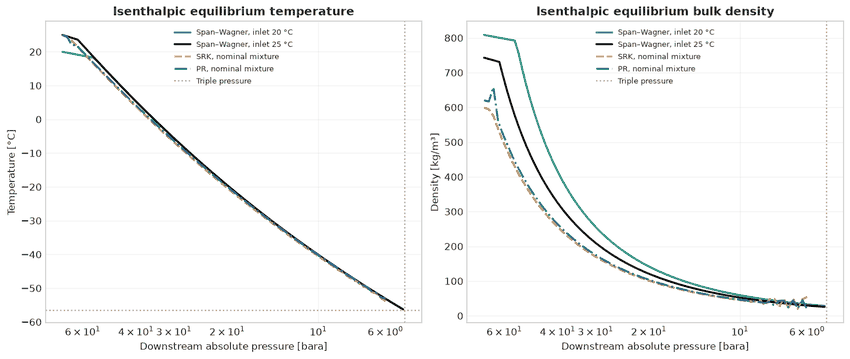

In [16]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 5.0),
    constrained_layout=True,
)

relief_styles = {
    "Span–Wagner, inlet 20 °C": ("#009E73", "-"),
    "Span–Wagner, inlet 25 °C": ("black", "-"),
    "SRK, nominal mixture": ("#E69F00", "--"),
    "PR, nominal mixture": ("#0072B2", "-."),
}

for path_name, (color, line_style) in relief_styles.items():
    subset = relief_paths[relief_paths["Path"] == path_name]
    axes[0].plot(
        subset["Pressure [bara]"],
        subset["Temperature [°C]"],
        color=color,
        linestyle=line_style,
        linewidth=2.0,
        label=path_name,
    )
    axes[1].plot(
        subset["Pressure [bara]"],
        subset["Density [kg/m³]"],
        color=color,
        linestyle=line_style,
        linewidth=2.0,
        label=path_name,
    )

for axis in axes:
    axis.axvline(
        CO2_TRIPLE_PRESSURE_PA / 1.0e5,
        color="#CC79A7",
        linestyle=":",
        linewidth=1.4,
        label="Triple pressure",
    )
    axis.set_xscale("log")
    axis.invert_xaxis()
    axis.set_xlabel("Downstream absolute pressure [bara]")

axes[0].axhline(
    CO2_TRIPLE_TEMPERATURE_K - 273.15,
    color="#CC79A7",
    linestyle=":",
    linewidth=1.4,
)
axes[0].set_title("Isenthalpic equilibrium temperature")
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend(fontsize=8.0)

axes[1].set_title("Isenthalpic equilibrium bulk density")
axes[1].set_ylabel("Density [kg/m³]")
axes[1].legend(fontsize=8.0)
plt.show()

In [17]:
selected_pressures_bara = [50.0, 20.0, 10.0, 6.0]
selected_relief_records = []

for path_name in relief_styles:
    subset = relief_paths[relief_paths["Path"] == path_name]
    for selected_pressure_bara in selected_pressures_bara:
        nearest_index = (
            subset["Pressure [bara]"] - selected_pressure_bara
        ).abs().idxmin()
        row = subset.loc[nearest_index]
        selected_relief_records.append(
            {
                "Path": path_name,
                "Pressure [bara]": float(row["Pressure [bara]"]),
                "Temperature [°C]": float(row["Temperature [°C]"]),
                "Vapour quality / gas beta [-]": float(
                    row["Vapour quality [-]"]
                ),
                "Density [kg/m³]": float(row["Density [kg/m³]"]),
            }
        )

selected_relief_table = pd.DataFrame(selected_relief_records)
display(selected_relief_table.round(5))

,Path,Pressure [bara],Temperature [°C],Vapour quality / gas beta [-],Density [kg/m³]
0,"Span–Wagner, inlet 20 °C",49.36794,13.75855,0.07482,625.43833
1,"Span–Wagner, inlet 20 °C",20.02971,-19.45429,0.33540,142.45950
2,"Span–Wagner, inlet 20 °C",9.96250,-40.22361,0.42592,58.98869
3,"Span–Wagner, inlet 20 °C",6.07472,-52.81989,0.47208,33.43910
4,"Span–Wagner, inlet 25 °C",49.36794,13.75855,0.17903,464.85545
5,"Span–Wagner, inlet 25 °C",20.02971,-19.45429,0.40287,121.41831
6,"Span–Wagner, inlet 25 °C",9.96250,-40.22361,0.48469,52.17021
7,"Span–Wagner, inlet 25 °C",6.07472,-52.81989,0.52717,30.03467
8,"SRK, nominal mixture",50.80788,13.07805,0.26374,370.68666
9,"SRK, nominal mixture",20.13229,-20.10224,0.48242,102.20663


**Interpretation.** The path follows the saturation region over much of the pressure
drop. Approaching the triple point, the predicted equilibrium temperature approaches
about −56.6 °C. Expansion to atmospheric pressure cannot be completed correctly with
the fluid-only path because solid CO₂ becomes relevant; an external jet can also exhibit
nonequilibrium flashing, slip, nucleation delay, and sublimation temperatures below the
fluid triple-point temperature.

The PR and SRK curves are not reference answers. They demonstrate how a cubic-EOS choice
can alter the predicted downstream temperature and density, especially when the inlet
mixture itself is close to a model-dependent phase boundary.

# Part 5 — HEM critical-flow screen

An equilibrium nozzle throat is not isenthalpic. For an adiabatic, reversible path from
the stagnation state to a candidate throat pressure,

$$\begin{aligned}s_t&=s_0\\u_t&=\sqrt{2(h_0-h_t)}\\G(P_t)&=\rho_t u_t\\G_{\mathrm{crit}}&=\max_{P_t}G(P_t)\end{aligned}$$

Here $G$ is mass flux in kg/(m²·s). The calculation assumes homogeneous equilibrium,
no slip, instantaneous phase equilibrium, one-dimensional flow, and no solid. It is a
thermodynamic capacity screen, not certified valve capacity.

In [18]:
def hem_profile(inlet_temperature_c, number_of_points=420):
    inlet_temperature_k = inlet_temperature_c + 273.15
    inlet_pressure_pa = 70.0e5
    inlet_enthalpy = PropsSI(
        "Hmass",
        "T",
        inlet_temperature_k,
        "P",
        inlet_pressure_pa,
        "CO2",
    )
    inlet_entropy = PropsSI(
        "Smass",
        "T",
        inlet_temperature_k,
        "P",
        inlet_pressure_pa,
        "CO2",
    )
    throat_pressures_pa = np.geomspace(
        1.01 * CO2_TRIPLE_PRESSURE_PA,
        0.999 * inlet_pressure_pa,
        number_of_points,
    )
    rows = []
    for throat_pressure_pa in throat_pressures_pa:
        throat_enthalpy = PropsSI(
            "Hmass",
            "P",
            throat_pressure_pa,
            "Smass",
            inlet_entropy,
            "CO2",
        )
        throat_density = PropsSI(
            "Dmass",
            "P",
            throat_pressure_pa,
            "Smass",
            inlet_entropy,
            "CO2",
        )
        throat_temperature_k = PropsSI(
            "T",
            "P",
            throat_pressure_pa,
            "Smass",
            inlet_entropy,
            "CO2",
        )
        throat_quality = PropsSI(
            "Q",
            "P",
            throat_pressure_pa,
            "Smass",
            inlet_entropy,
            "CO2",
        )
        velocity = math.sqrt(
            max(0.0, 2.0 * (inlet_enthalpy - throat_enthalpy))
        )
        rows.append(
            {
                "Inlet [°C]": inlet_temperature_c,
                "Throat pressure [bara]": throat_pressure_pa / 1.0e5,
                "Throat temperature [°C]": throat_temperature_k - 273.15,
                "Throat quality [-]": throat_quality,
                "Throat density [kg/m³]": throat_density,
                "Velocity [m/s]": velocity,
                "Mass flux [kg/(m²·s)]": throat_density * velocity,
            }
        )
    return pd.DataFrame(rows)


hem_profiles = pd.concat(
    [hem_profile(20.0), hem_profile(25.0)],
    ignore_index=True,
)

critical_records = []
for inlet_temperature_c in [20.0, 25.0]:
    subset = hem_profiles[
        hem_profiles["Inlet [°C]"] == inlet_temperature_c
    ]
    critical_row = subset.loc[
        subset["Mass flux [kg/(m²·s)]"].idxmax()
    ]
    critical_records.append(critical_row.to_dict())

critical_table = pd.DataFrame(critical_records)
display(critical_table.round(5))

,Inlet [°C],Throat pressure [bara],Throat temperature [°C],Throat quality [-],Throat density [kg/m³],Velocity [m/s],Mass flux [kg/(m²·s)]
0,20.0,53.92505,17.43656,0.00289,791.07086,63.26880,50050.10366
1,25.0,51.00391,15.10799,0.14607,513.79538,75.83758,38964.99632


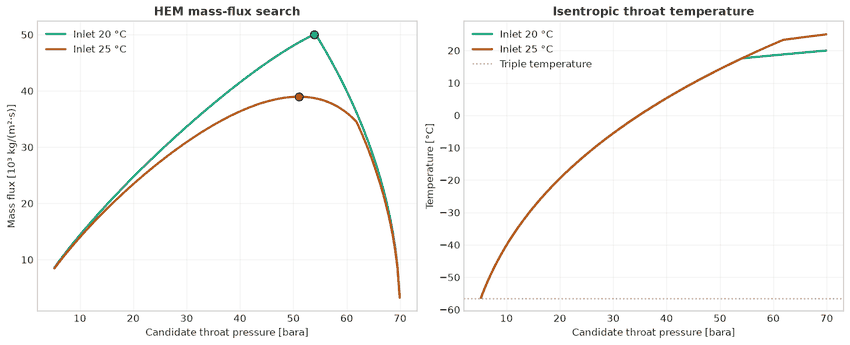

In [19]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.8),
    constrained_layout=True,
)

for inlet_temperature_c, color in [(20.0, "#009E73"), (25.0, "#D55E00")]:
    subset = hem_profiles[
        hem_profiles["Inlet [°C]"] == inlet_temperature_c
    ]
    critical_row = critical_table[
        critical_table["Inlet [°C]"] == inlet_temperature_c
    ].iloc[0]
    axes[0].plot(
        subset["Throat pressure [bara]"],
        subset["Mass flux [kg/(m²·s)]"] / 1000.0,
        color=color,
        linewidth=2.2,
        label=f"Inlet {inlet_temperature_c:.0f} °C",
    )
    axes[0].scatter(
        [critical_row["Throat pressure [bara]"]],
        [critical_row["Mass flux [kg/(m²·s)]"] / 1000.0],
        color=color,
        edgecolor="black",
        s=65,
        zorder=5,
    )
    axes[1].plot(
        subset["Throat pressure [bara]"],
        subset["Throat temperature [°C]"],
        color=color,
        linewidth=2.2,
        label=f"Inlet {inlet_temperature_c:.0f} °C",
    )

axes[0].set_title("HEM mass-flux search")
axes[0].set_xlabel("Candidate throat pressure [bara]")
axes[0].set_ylabel("Mass flux [10³ kg/(m²·s)]")
axes[0].legend()

axes[1].axhline(
    CO2_TRIPLE_TEMPERATURE_K - 273.15,
    color="#CC79A7",
    linestyle=":",
    linewidth=1.4,
    label="Triple temperature",
)
axes[1].set_title("Isentropic throat temperature")
axes[1].set_xlabel("Candidate throat pressure [bara]")
axes[1].set_ylabel("Temperature [°C]")
axes[1].legend()
plt.show()

In [20]:
illustrative_relief_load_kg_s = 25.0
illustrative_discharge_coefficient = 0.85
area_records = []

for _, row in critical_table.iterrows():
    mass_flux = float(row["Mass flux [kg/(m²·s)]"])
    flow_area_m2 = illustrative_relief_load_kg_s / (
        illustrative_discharge_coefficient * mass_flux
    )
    equivalent_diameter_mm = 1000.0 * math.sqrt(
        4.0 * flow_area_m2 / math.pi
    )
    area_records.append(
        {
            "Inlet [°C]": float(row["Inlet [°C]"]),
            "HEM critical flux [kg/(m²·s)]": mass_flux,
            "Illustrative load [kg/s]": illustrative_relief_load_kg_s,
            "HEM screen area [mm²]": 1.0e6 * flow_area_m2,
            "Equivalent diameter [mm]": equivalent_diameter_mm,
        }
    )

area_screen_table = pd.DataFrame(area_records)
display(area_screen_table.round(4))

,Inlet [°C],HEM critical flux [kg/(m²·s)],Illustrative load [kg/s],HEM screen area [mm²],Equivalent diameter [mm]
0,20.0,50050.1037,25.0,587.6464,27.3535
1,25.0,38964.9963,25.0,754.8253,31.0012


**Interpretation.** A five-degree inlet-temperature difference changes the dense-fluid
state and the HEM critical flux substantially. The calculated equivalent diameter is
only a thermodynamic comparison for a stated load and coefficient. It excludes certified
capacity factors, device geometry, inlet pressure loss, backpressure, reaction force,
and nonequilibrium or solid effects, so it must not be used as a final valve or orifice
size.

# Part 6 — Transient vessel blowdown and minimum temperature

The blowdown model uses a homogeneous equilibrium vessel and the open-system balances

$$\frac{dm}{dt}=-\dot m$$

$$\frac{d(mu)}{dt}=\dot Q_{wf}-\dot m h$$

with a lumped metal wall,

$$M_w c_{p,w}\frac{dT_w}{dt}=UA_o(T_a-T_w)-UA_i(T_w-T_f)$$

At each step the vent mass flow is $\dot m=C_d A G_{\mathrm{crit}}$. The fluid state is
recovered from density and internal energy with Span–Wagner. Two cases are compared:
an adiabatic exterior and a moderate ambient heat leak. The simulation stops just above
the triple pressure.

This is intentionally a screening model. Real equipment requires geometry-resolved heat
transfer, wall conduction, nozzle and connected-pipe inventories, phase slip, possible
stratification, non-equilibrium nucleation, and solid-CO₂ handling.

In [21]:
def critical_mass_flux_from_state(
    pressure_pa,
    enthalpy_j_per_kg,
    entropy_j_per_kg_k,
    number_of_points=40,
):
    minimum_pressure_pa = 1.01 * CO2_TRIPLE_PRESSURE_PA
    if pressure_pa <= 1.03 * CO2_TRIPLE_PRESSURE_PA:
        return {
            "mass_flux": 0.0,
            "throat_pressure_pa": np.nan,
            "throat_temperature_k": np.nan,
            "throat_quality": np.nan,
        }

    candidate_pressures_pa = np.geomspace(
        minimum_pressure_pa,
        0.999 * pressure_pa,
        number_of_points,
    )
    best = None
    for candidate_pressure_pa in candidate_pressures_pa:
        throat_enthalpy = PropsSI(
            "Hmass",
            "P",
            candidate_pressure_pa,
            "Smass",
            entropy_j_per_kg_k,
            "CO2",
        )
        throat_density = PropsSI(
            "Dmass",
            "P",
            candidate_pressure_pa,
            "Smass",
            entropy_j_per_kg_k,
            "CO2",
        )
        throat_temperature_k = PropsSI(
            "T",
            "P",
            candidate_pressure_pa,
            "Smass",
            entropy_j_per_kg_k,
            "CO2",
        )
        throat_quality = PropsSI(
            "Q",
            "P",
            candidate_pressure_pa,
            "Smass",
            entropy_j_per_kg_k,
            "CO2",
        )
        velocity = math.sqrt(
            max(0.0, 2.0 * (enthalpy_j_per_kg - throat_enthalpy))
        )
        mass_flux = throat_density * velocity
        candidate = {
            "mass_flux": mass_flux,
            "throat_pressure_pa": candidate_pressure_pa,
            "throat_temperature_k": throat_temperature_k,
            "throat_quality": throat_quality,
        }
        if best is None or mass_flux > best["mass_flux"]:
            best = candidate
    return best


def simulate_blowdown(ambient_ua_w_per_k):
    vessel_volume_m3 = 10.0
    initial_temperature_k = 298.15
    initial_pressure_pa = 70.0e5
    ambient_temperature_k = 298.15
    vent_diameter_m = 0.020
    discharge_coefficient = 0.85
    internal_ua_w_per_k = 800.0
    wall_mass_kg = 2500.0
    wall_heat_capacity_j_per_kg_k = 500.0
    time_step_s = 2.0
    maximum_time_s = 3600.0

    vent_area_m2 = math.pi * vent_diameter_m**2 / 4.0
    initial_density = PropsSI(
        "Dmass",
        "T",
        initial_temperature_k,
        "P",
        initial_pressure_pa,
        "CO2",
    )
    mass_kg = initial_density * vessel_volume_m3
    initial_internal_energy = PropsSI(
        "Umass",
        "T",
        initial_temperature_k,
        "P",
        initial_pressure_pa,
        "CO2",
    )
    total_internal_energy_j = mass_kg * initial_internal_energy
    wall_temperature_k = initial_temperature_k
    wall_heat_capacity_j_per_k = (
        wall_mass_kg * wall_heat_capacity_j_per_kg_k
    )
    records = []
    cached_critical_state = None
    number_of_steps = int(maximum_time_s / time_step_s) + 1

    for step_index in range(number_of_steps):
        density = mass_kg / vessel_volume_m3
        internal_energy = total_internal_energy_j / mass_kg
        pressure_pa = PropsSI(
            "P",
            "Dmass",
            density,
            "Umass",
            internal_energy,
            "CO2",
        )
        fluid_temperature_k = PropsSI(
            "T",
            "Dmass",
            density,
            "Umass",
            internal_energy,
            "CO2",
        )
        enthalpy = PropsSI(
            "Hmass",
            "Dmass",
            density,
            "Umass",
            internal_energy,
            "CO2",
        )
        entropy = PropsSI(
            "Smass",
            "Dmass",
            density,
            "Umass",
            internal_energy,
            "CO2",
        )
        quality = PropsSI(
            "Q",
            "Dmass",
            density,
            "Umass",
            internal_energy,
            "CO2",
        )

        near_triple_boundary = (
            pressure_pa <= 1.03 * CO2_TRIPLE_PRESSURE_PA
        )
        if near_triple_boundary:
            cached_critical_state = {
                "mass_flux": 0.0,
                "throat_pressure_pa": np.nan,
                "throat_temperature_k": np.nan,
                "throat_quality": np.nan,
            }
        elif step_index % 2 == 0 or cached_critical_state is None:
            cached_critical_state = critical_mass_flux_from_state(
                pressure_pa,
                enthalpy,
                entropy,
            )
        mass_flux = cached_critical_state["mass_flux"]
        mass_flow_kg_s = (
            discharge_coefficient * vent_area_m2 * mass_flux
        )

        records.append(
            {
                "Time [s]": step_index * time_step_s,
                "Pressure [bara]": pressure_pa / 1.0e5,
                "Fluid temperature [°C]": fluid_temperature_k - 273.15,
                "Wall temperature [°C]": wall_temperature_k - 273.15,
                "Mass [kg]": mass_kg,
                "Vessel quality [-]": quality,
                "Vent mass flow [kg/s]": mass_flow_kg_s,
                "Critical flux [kg/(m²·s)]": mass_flux,
                "Critical throat [bara]": (
                    cached_critical_state["throat_pressure_pa"] / 1.0e5
                ),
            }
        )

        if near_triple_boundary:
            break
        if mass_flow_kg_s <= 0.0:
            break

        fluid_wall_heat_w = internal_ua_w_per_k * (
            wall_temperature_k - fluid_temperature_k
        )
        ambient_wall_heat_w = ambient_ua_w_per_k * (
            ambient_temperature_k - wall_temperature_k
        )
        discharged_mass_kg = min(
            mass_flow_kg_s * time_step_s,
            0.005 * mass_kg,
        )
        total_internal_energy_j += (
            fluid_wall_heat_w * time_step_s
            - discharged_mass_kg * enthalpy
        )
        mass_kg -= discharged_mass_kg
        wall_temperature_k += (
            (ambient_wall_heat_w - fluid_wall_heat_w)
            * time_step_s
            / wall_heat_capacity_j_per_k
        )

    return pd.DataFrame(records)

In [22]:
blowdown_started = time.perf_counter()
blowdown_cases = {
    "Adiabatic exterior": simulate_blowdown(0.0),
    "Ambient heat leak, UA = 150 W/K": simulate_blowdown(150.0),
}
blowdown_elapsed_s = time.perf_counter() - blowdown_started
print(f"Blowdown cases executed in {blowdown_elapsed_s:.2f} s")

blowdown_summary_records = []
for case_name, case_table in blowdown_cases.items():
    final_row = case_table.iloc[-1]
    blowdown_summary_records.append(
        {
            "Case": case_name,
            "Time to stop [s]": float(final_row["Time [s]"]),
            "Final pressure [bara]": float(final_row["Pressure [bara]"]),
            "Minimum fluid [°C]": float(
                case_table["Fluid temperature [°C]"].min()
            ),
            "Minimum wall [°C]": float(
                case_table["Wall temperature [°C]"].min()
            ),
            "Remaining mass [kg]": float(final_row["Mass [kg]"]),
            "Final vent flow [kg/s]": float(
                final_row["Vent mass flow [kg/s]"]
            ),
        }
    )

blowdown_summary = pd.DataFrame(blowdown_summary_records)
display(blowdown_summary.round(4))

Blowdown cases executed in 15.12 s


,Case,Time to stop [s],Final pressure [bara],Minimum fluid [°C],Minimum wall [°C],Remaining mass [kg],Final vent flow [kg/s]
0,Adiabatic exterior,2062.0,5.3337,-55.8815,-12.0860,212.4620,0.0
1,"Ambient heat leak, UA = 150 W/K",2076.0,5.3342,-55.8793,-10.1619,207.8648,0.0


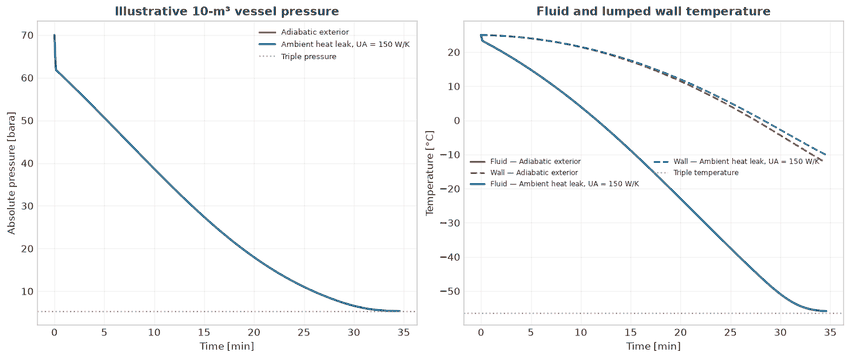

In [23]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 5.0),
    constrained_layout=True,
)

case_colors = {
    "Adiabatic exterior": "#D55E00",
    "Ambient heat leak, UA = 150 W/K": "#0072B2",
}

for case_name, case_table in blowdown_cases.items():
    color = case_colors[case_name]
    time_minutes = case_table["Time [s]"] / 60.0
    axes[0].plot(
        time_minutes,
        case_table["Pressure [bara]"],
        color=color,
        linewidth=2.0,
        label=case_name,
    )
    axes[1].plot(
        time_minutes,
        case_table["Fluid temperature [°C]"],
        color=color,
        linewidth=2.0,
        label=f"Fluid — {case_name}",
    )
    axes[1].plot(
        time_minutes,
        case_table["Wall temperature [°C]"],
        color=color,
        linestyle="--",
        linewidth=1.8,
        label=f"Wall — {case_name}",
    )

axes[0].axhline(
    CO2_TRIPLE_PRESSURE_PA / 1.0e5,
    color="#CC79A7",
    linestyle=":",
    linewidth=1.4,
    label="Triple pressure",
)
axes[0].set_title("Illustrative 10-m³ vessel pressure")
axes[0].set_xlabel("Time [min]")
axes[0].set_ylabel("Absolute pressure [bara]")
axes[0].legend(fontsize=8.0)

axes[1].axhline(
    CO2_TRIPLE_TEMPERATURE_K - 273.15,
    color="#CC79A7",
    linestyle=":",
    linewidth=1.4,
    label="Triple temperature",
)
axes[1].set_title("Fluid and lumped wall temperature")
axes[1].set_xlabel("Time [min]")
axes[1].set_ylabel("Temperature [°C]")
axes[1].legend(fontsize=7.4, ncol=2)
plt.show()

**Interpretation.** The equilibrium fluid approaches the triple-point temperature while
the lumped wall remains much warmer because of its thermal inertia. Neither value is a
universal minimum design metal temperature. Local nozzle, small-bore branch, valve body,
support, and downstream-pipe temperatures can differ sharply from the vessel-average
wall. The external jet can enter a vapour–solid regime not calculated here.

The heat-leak case also illustrates why a thermodynamic flash alone cannot establish a
metal temperature: wall mass, internal heat transfer, ambient heat input, event duration,
and geometry all matter.

# Part 7 — Scenario-to-model decision table

| Engineering question | Required thermodynamic path | Minimum credible model | Additional work before design closure |
|---|---|---|---|
| Final cooler phase state | TP flash and uncertainty grid | EOS-CG for dry CCS mixture | Measured composition, water model, operating tolerances |
| Compressor power | PS/PH equipment calculations | PR/SRK with reference audit | Compressor map, stage losses, driver and anti-surge limits |
| PSV downstream temperature | Isenthalpic equilibrium flash | Reference pure fluid or qualified mixture EOS | Backpressure, pipe heat transfer, solid and dispersion model |
| Relief throat capacity | Isentropic HEM or qualified two-phase method | Reference EOS | Certified sizing method, discharge coefficient, nonequilibrium |
| Vessel blowdown MDMT screen | Transient mass and energy balance | Reference EOS plus wall heat balance | Geometry-resolved wall model, material toughness, stress history |
| Atmospheric release | Vapour–solid, jet, and dispersion model | Solid-capable CO₂ model | CFD/dispersion, icing, visibility, toxicity and exclusion zones |
| Wet CO₂ system | Gas–liquid–aqueous equilibrium | CPA or validated aqueous model | Corrosion, ice/hydrate, acid chemistry and water specification |

The governing principle is to use one EOS consistently within a calculation, then audit
decision-critical states against a more accurate or more appropriate model. Do not mix
enthalpies from different packages without aligning reference states.

## Numerical and engineering validation

The checks below enforce the main invariants: normalized composition, accurate EOS-CG
pure-CO₂ density, positive compressor work, pressure targets, mass closure, expected
EOS-CG phase sensitivity, a true interior HEM maximum, monotonic depressurization, and
termination above the triple pressure.

In [24]:
eoscg_errors = pure_density_table[
    pure_density_table["Model"] == "EOS-CG"
]["Relative error [%]"].abs()

pressure_targets_met = True
mass_closure_met = True
for model_name, train in compression_trains.items():
    result_subset = compression_results[
        compression_results["Model"] == model_name
    ]
    pressure_targets_met = pressure_targets_met and bool(
        np.allclose(
            result_subset["Discharge [bara]"].to_numpy(),
            train["stage_pressures_bara"],
            rtol=0.0,
            atol=1.0e-8,
        )
    )
    feed_mass = float(train["feed"].getFlowRate("kg/hr"))
    final_gas_mass = float(
        train["separators"][-1].getGasOutStream().getFlowRate("kg/hr")
    )
    final_liquid_mass = float(
        train["separators"][-1]
        .getLiquidOutStream()
        .getFlowRate("kg/hr")
    )
    relative_residual = abs(
        final_gas_mass + final_liquid_mass - feed_mass
    ) / feed_mass
    mass_closure_met = mass_closure_met and relative_residual < 1.0e-10

nominal_eoscg_25 = nominal_state_table[
    (nominal_state_table["Temperature [°C]"] == 25.0)
    & (nominal_state_table["Model"] == "EOS-CG")
].iloc[0]

hem_maxima_interior = True
for inlet_temperature_c in [20.0, 25.0]:
    subset = hem_profiles[
        hem_profiles["Inlet [°C]"] == inlet_temperature_c
    ]
    maximum_index = subset["Mass flux [kg/(m²·s)]"].idxmax()
    hem_maxima_interior = hem_maxima_interior and maximum_index not in {
        subset.index.min(),
        subset.index.max(),
    }

blowdown_pressure_monotonic = all(
    bool((case_table["Pressure [bara]"].diff().dropna() < 0.0).all())
    for case_table in blowdown_cases.values()
)
blowdown_above_triple = all(
    float(case_table["Pressure [bara]"].iloc[-1])
    > CO2_TRIPLE_PRESSURE_PA / 1.0e5
    for case_table in blowdown_cases.values()
)
blowdown_near_triple_temperature = all(
    abs(
        float(case_table["Fluid temperature [°C]"].iloc[-1])
        - (CO2_TRIPLE_TEMPERATURE_K - 273.15)
    )
    < 1.0
    for case_table in blowdown_cases.values()
)

checks = {
    "composition normalized": math.isclose(
        sum(NOMINAL_COMPOSITION.values()),
        1.0,
        abs_tol=1.0e-12,
    ),
    "EOS-CG pure-CO2 density within 0.1% of reference": bool(
        (eoscg_errors < 0.1).all()
    ),
    "all compressor powers finite and positive": bool(
        np.isfinite(compression_results["Power [MW]"]).all()
        and (compression_results["Power [MW]"] > 0.0).all()
    ),
    "all stage pressure targets met": pressure_targets_met,
    "compression-train total mass closure": mass_closure_met,
    "EOS-CG detects nominal two-phase state at 25 C": int(
        nominal_eoscg_25["Phases [-]"]
    )
    == 2,
    "HEM critical maxima are interior": hem_maxima_interior,
    "HEM critical fluxes finite and positive": bool(
        np.isfinite(critical_table["Mass flux [kg/(m²·s)]"]).all()
        and (critical_table["Mass flux [kg/(m²·s)]"] > 0.0).all()
    ),
    "blowdown pressure decreases monotonically": blowdown_pressure_monotonic,
    "blowdown stops above triple pressure": blowdown_above_triple,
    "blowdown fluid approaches triple temperature": (
        blowdown_near_triple_temperature
    ),
    "lumped wall remains warmer than final fluid": all(
        float(case_table["Wall temperature [°C]"].iloc[-1])
        > float(case_table["Fluid temperature [°C]"].iloc[-1])
        for case_table in blowdown_cases.values()
    ),
}

assert all(checks.values()), checks
validation_table = pd.DataFrame(
    {
        "Check": list(checks.keys()),
        "Passed": list(checks.values()),
    }
)
display(validation_table)
print(f"All {len(checks)} engineering checks passed.")

All 12 engineering checks passed.


,Check,Passed
0,composition normalized,True
1,EOS-CG pure-CO2 density within 0.1% of reference,True
2,all compressor powers finite and positive,True
3,all stage pressure targets met,True
4,compression-train total mass closure,True
5,EOS-CG detects nominal two-phase state at 25 C,True
6,HEM critical maxima are interior,True
7,HEM critical fluxes finite and positive,True
8,blowdown pressure decreases monotonically,True
9,blowdown stops above triple pressure,True


# Conclusions

1. **70 bara at 20–25 °C is not supercritical for pure CO₂.** It is a subcritical,
   dense state close to the vapour–liquid boundary, especially at 25 °C.
2. **EOS choice matters.** EOS-CG follows Span–Wagner pure-CO₂ density closely, while
   PR and SRK underpredict dense-fluid density in the selected range.
3. **Small impurities can change the phase state.** At 70 bara and 25 °C, the synthetic
   1 mol% N₂/O₂/Ar case is single phase with PR/SRK but two phase with EOS-CG.
4. **The five-stage compressor train is numerically robust with PR and SRK**, and the
   two cubic models give similar power. Reference-EOS auditing is still required at the
   final cooler and other decision-critical states.
5. **An isenthalpic downstream flash is not a PSV capacity calculation.** It is useful
   for downstream equilibrium temperature and phase screening only.
6. **HEM capacity is highly temperature-sensitive** near the dense-fluid boundary.
   Certified sizing must add the approved device and two-phase-flow methodology.
7. **Blowdown can approach the CO₂ triple point.** The average wall remains warmer in
   the lumped model, but local metal, valve, and downstream-pipe temperatures need a
   geometry-specific thermal assessment.
8. **Fluid-only EOS results must stop at the triple boundary.** Atmospheric discharge
   requires solid-CO₂ and nonequilibrium jet/dispersion analysis.

## Required inputs before applying the workflow

- measured wet and dry composition with uncertainty;
- normal, start-up, shutdown, blocked-in, and relief pressure-temperature envelopes;
- relief load cases, set pressure, accumulation, and backpressure;
- equipment and piping inventories and geometry;
- wall material, thickness, heat capacity, insulation, and ambient boundary conditions;
- water and impurity specifications plus corrosion and solid-formation criteria; and
- the approved relief, depressurization, materials, and dispersion standards.

## Limitations

- All inputs are synthetic and the dry composition is not a product specification.
- EOS-CG and GERG-2008 are used for equilibrium property audits, not as a guarantee of
  accuracy outside their component and state ranges.
- The mixture phase map is finite-grid equilibrium screening.
- The compressor train omits maps, surge, stonewall, driver limits, interstage pressure
  losses, mechanical losses, and dynamic control.
- The isenthalpic path omits nozzle kinetics, heat transfer, slip, and solids.
- The HEM screen assumes instantaneous equilibrium and homogeneous two-phase flow.
- The blowdown uses a homogeneous vessel, a lumped wall, and pure CO₂. It does not model
  stratification, local metal gradients, connected piping, or external dispersion.
- The calculation stops above the triple pressure and does not calculate dry-ice mass.
- The results are educational engineering evidence, not a certified design basis.

## Literature and authoritative references

1. R. Span and W. Wagner, “A New Equation of State for Carbon Dioxide Covering the
   Fluid Region from the Triple-Point Temperature to 1100 K at Pressures up to
   800 MPa,” *J. Phys. Chem. Ref. Data* 25, 1509–1596 (1996),
   [doi:10.1063/1.555991](https://doi.org/10.1063/1.555991).
2. J. Gernert and R. Span, “EOS-CG: A Helmholtz energy mixture model for humid gases
   and CCS mixtures,” *J. Chem. Thermodynamics* 93, 274–293 (2016),
   [doi:10.1016/j.jct.2015.05.015](https://doi.org/10.1016/j.jct.2015.05.015).
3. T. Neumann et al., “EOS-CG-2021: A Mixture Model for the Calculation of
   Thermodynamic Properties of CCS Mixtures,” *Int. J. Thermophysics* 44, 178
   (2023),
   [doi:10.1007/s10765-023-03263-6](https://doi.org/10.1007/s10765-023-03263-6).
4. O. Kunz and W. Wagner, “The GERG-2008 Wide-Range Equation of State for Natural
   Gases and Other Mixtures,” *J. Chem. Eng. Data* 57, 3032–3091 (2012),
   [doi:10.1021/je300655b](https://doi.org/10.1021/je300655b).
5. J. Staubach et al., “Modeling Thermodynamic Properties of Mixtures of CO₂ + O₂
   in the Allam Cycle by Equations of State,” *Int. J. Thermophysics* 44, 182
   (2023),
   [doi:10.1007/s10765-023-03297-w](https://doi.org/10.1007/s10765-023-03297-w).
6. D. Jamois et al., “An experimental setup for investigating the blowdown of liquid
   CO₂ down to −50 °C,” *Int. J. Greenhouse Gas Control* 129, 103974 (2023),
   [doi:10.1016/j.ijggc.2023.103974](https://doi.org/10.1016/j.ijggc.2023.103974).
7. M. Drescher et al., “Blowdown of CO₂ vessels at low and medium pressure
   conditions: Experiments and simulations,” *Process Safety and Environmental
   Protection* 179, 907–927 (2023),
   [doi:10.1016/j.psep.2023.03.064](https://doi.org/10.1016/j.psep.2023.03.064).
8. [NeqSim GERG-2008 and EOS-CG documentation](https://github.com/equinor/neqsim/blob/master/docs/thermo/gerg2008_eoscg.md).
9. [CoolProp CO₂ model documentation](https://coolprop.org/fluid_properties/fluids/CarbonDioxide.html).
10. [API Standard 521 overview](https://www.api.org/products-and-services/standards/important-standards-announcements/standard521) and
    [API 520 Part I overview](https://www.api.org/products-and-services/standards/important-standards-announcements/520parti).
11. [ISO 4126-10:2024 — two-phase safety-device sizing](https://www.iso.org/standard/76057.html).

The pure-CO₂ quantitative benchmark is a direct model-to-reference comparison against
the published Span–Wagner formulation. The mixture conclusions are compared with the
EOS-CG/EOS-CG-2021 scope and the experimental literature cited above; no proprietary or
project data are embedded.

## Suggested extensions

1. Replace the synthetic composition with an approved uncertainty envelope and rerun the
   EOS-CG final-cooler map.
2. Add a water-qualified CPA case and calculate water dropout before and after each
   intercooler.
3. Compare HEM with a nonequilibrium two-phase critical-flow method over the same inlet
   envelope.
4. Add a multi-node wall and connected-pipe thermal model, then compare local and average
   metal temperatures.
5. Couple the source term to a validated vapour–solid release and dispersion model.
6. Fit or verify binary interaction parameters only against traceable experimental data,
   never to force agreement with an expected answer.